In [1]:
import os
import sys
sys.path.append("..")
import nibabel as nib
import matplotlib.pyplot as plt
#from ipywidgets import interact
import numpy as np
#import ipywidgets as widgets
import pandas as pd
from tqdm import tqdm
import csv
import numpy as np
import random

import torch
from monai import transforms
import utils.custom_transforms as custom_transforms
from monai.data import CacheDataset, DataLoader, ThreadDataLoader


In [2]:
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#ROOT_DIR = "/home/theotime/bettik/"
ROOT_DIR = "/home/fehrdelt/bettik/"

In [3]:

final_adc_dataset_small_HCP_YA = ROOT_DIR+"datasets/final_adc_dataset_small/HCP-YA_registered/"
final_adc_dataset_small_Dallas = ROOT_DIR+"datasets/final_adc_dataset_small/Dallas_registered/"
final_adc_dataset_small_AINI_stroke_ait = ROOT_DIR+"datasets/final_adc_dataset_small/AIT_final_registered/"
final_adc_dataset_small_ixi = ROOT_DIR+"datasets/final_adc_dataset_small/ixi_registered/"
final_adc_dataset_small_isles = ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"

final_flair_dataset_small_dallas = ROOT_DIR+"datasets/final_flair_dataset_small/dallas_registered/"
final_flair_dataset_small_lemon = ROOT_DIR+"datasets/final_flair_dataset_small/lemon_registered/"
final_flair_dataset_small_oasis = ROOT_DIR+"datasets/final_flair_dataset_small/oasis_registered/"

final_flair_dataset_small_isles = ROOT_DIR+"datasets/final_flair_dataset_small/isles_registered/"
final_flair_dataset_small_brats = ROOT_DIR+"datasets/final_flair_dataset_small/brats_registered/"

IXI_T1_dataset = ROOT_DIR+"datasets/dataset_IXI_T1_brain_extraction/"

### Display middle slice of every nifti file in folder

In [8]:
def display_middle_slice_z(folder_path, nb_images, page_number, figsize, normalize_from_histogram_peak=True, hist_norm_target_value=200, max_display_value=3000):
    # List all files in the folder
    files = os.listdir(folder_path)[nb_images*page_number:nb_images*(page_number+1)]

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices and their histograms
    rows = int(np.sqrt(nb_images))
    fig, axes = plt.subplots(rows, rows, figsize=(figsize, figsize+2))
    plt.tight_layout()

    for i, nifti_file in enumerate(nifti_files):
        # Load the NIFTI image
        img_path = os.path.join(folder_path, nifti_file)
        img = nib.load(img_path)
        data = img.get_fdata()

        # Get the middle slice index for the z-axis
        middle_slice_z = data.shape[2] // 2

        image_slice = data[:, :, middle_slice_z]


        if normalize_from_histogram_peak:
            # Compute the histogram of the image slice
            hist, bins = np.histogram(image_slice.flatten(), bins=100, range=(np.max(image_slice)/5.0, np.max(image_slice)))

            # Find the value corresponding to the maximum of the histogram
            most_occurred_pixel_value = bins[np.argmax(hist)]

            image_slice = image_slice/most_occurred_pixel_value*hist_norm_target_value # scale it so the peak is always at hist_norm_target_value

        # Display the middle slice for the z-axis
        if normalize_from_histogram_peak:
            axes[i//rows, (i%rows)].imshow(image_slice, cmap='gray', vmin=0, vmax=max_display_value) # flair: vmax=450
        else:
            axes[i//rows, (i%rows)].imshow(image_slice, cmap='gray', vmin=0, vmax=np.max(image_slice))
        
        axes[i//rows, (i%rows)].set_title(f'{i+(page_number*nb_images)}')
        axes[i//rows, (i%rows)].axis("off")

        axes[i//rows, (i%rows)].set_aspect('auto') # Set the aspect ratio to auto to match the imshow plot
        axes[i//rows, (i%rows)].set_box_aspect(1)  # Set the aspect ratio of the histogram subplot


    # Set the title of the figure
    fig.suptitle('Middle slices and histograms for all NIFTI files')
    
    # Show the plot
    plt.show()


In [5]:
def display_middle_slice_z_with_histogram(folder_path, nb_images, page_number, figsize, normalize_from_histogram_peak=True, hist_norm_target_value=200, max_display_value=3000):
    # List all files in the folder
    files = os.listdir(folder_path)[nb_images*page_number:nb_images*(page_number+1)]

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices and their histograms
    rows = int(np.sqrt(nb_images))
    fig, axes = plt.subplots(rows, rows * 2, figsize=(figsize, figsize//2 + 2))
    plt.tight_layout()

    for i, nifti_file in enumerate(nifti_files):
        # Load the NIFTI image
        img_path = os.path.join(folder_path, nifti_file)
        img = nib.load(img_path)
        data = img.get_fdata()

        # Get the middle slice index for the z-axis
        middle_slice_z = data.shape[2] // 2

        image_slice = data[:, :, middle_slice_z]


        if normalize_from_histogram_peak:
            # Compute the histogram of the image slice
            hist, bins = np.histogram(image_slice.flatten(), bins=100, range=(np.max(image_slice)/5.0, np.max(image_slice)))

            # Find the value corresponding to the maximum of the histogram
            most_occurred_pixel_value = bins[np.argmax(hist)]

            image_slice = image_slice/most_occurred_pixel_value*hist_norm_target_value # scale it so the peak is always at hist_norm_target_value

        # Display the middle slice for the z-axis
        if normalize_from_histogram_peak:
            axes[i//rows, (i%rows)*2].imshow(image_slice, cmap='gray', vmin=0, vmax=max_display_value) # flair: vmax=450
        else:
            axes[i//rows, (i%rows)*2].imshow(image_slice, cmap='gray', vmin=0, vmax=np.max(image_slice))
        axes[i//rows, (i%rows)*2].set_title(f'{i+(page_number*nb_images)}')
        axes[i//rows, (i%rows)*2].axis("off")

        axes[i//rows, (i%rows)*2].set_aspect('auto') # Set the aspect ratio to auto to match the imshow plot
        axes[i//rows, (i%rows)*2].set_box_aspect(1)  # Set the aspect ratio of the histogram subplot


        hist_values, bin_edges, _ = axes[i//rows, (i%rows)*2 + 1].hist(image_slice.flatten(), bins=100, range=(10,max_display_value)) #flair: range=(1, 450)
        axes[i//rows, (i%rows)*2 + 1].set_box_aspect(1)  # Set the aspect ratio of the histogram subplot

    # Set the title of the figure
    fig.suptitle('Middle slices and histograms for all NIFTI files')
    
    # Show the plot
    plt.show()


In [32]:
problematic_files = [70, 81, 98, 107, 141, 190, 204, 220, 335, 396, 412, 420, 423, 424, 427, 431, 433, 446, 477, 524, 586, 629, 633, 666, 733, 742]

In [33]:
filelist = os.listdir(final_flair_dataset_small_oasis)

for file in problematic_files:
    print(filelist[file])
    """ img_path = os.path.join(final_flair_dataset_small_oasis, filelist[file])
    img = nib.load(img_path)
    data = img.get_fdata()
    mid_z = data.shape[2] // 2
    slice_img = data[:, :, mid_z]
    vmax = np.percentile(slice_img, 99)
    plt.figure(figsize=(4, 4))
    plt.imshow(slice_img, cmap='gray', vmin=0, vmax=vmax)
    plt.title(filelist[file])
    plt.axis('off')
    plt.show() """

sub-OAS31041_ses-d1426_FLAIR.nii.gz
sub-OAS30586_ses-d1149_FLAIR.nii.gz
sub-OAS30204_ses-d0020_FLAIR.nii.gz
sub-OAS30637_ses-d0079_FLAIR.nii.gz
sub-OAS30479_ses-d2421_FLAIR.nii.gz
sub-OAS31020_ses-d0651_FLAIR.nii.gz
sub-OAS30006_ses-d2342_FLAIR.nii.gz
sub-OAS31019_ses-d1370_FLAIR.nii.gz
sub-OAS30322_ses-d3851_FLAIR.nii.gz
sub-OAS30483_ses-d0947_FLAIR.nii.gz
sub-OAS30769_ses-d1547_FLAIR.nii.gz
sub-OAS30344_ses-d2375_FLAIR.nii.gz
sub-OAS30417_ses-d0107_FLAIR.nii.gz
sub-OAS30445_ses-d0133_FLAIR.nii.gz
sub-OAS30204_ses-d0033_FLAIR.nii.gz
sub-OAS30594_ses-d0066_FLAIR.nii.gz
sub-OAS30796_ses-d0079_FLAIR.nii.gz
sub-OAS30219_ses-d1184_FLAIR.nii.gz
sub-OAS30065_ses-d2009_FLAIR.nii.gz
sub-OAS30182_ses-d0101_FLAIR.nii.gz
sub-OAS31114_ses-d3479_FLAIR.nii.gz
sub-OAS30919_ses-d3650_run-02_FLAIR.nii.gz
sub-OAS30026_ses-d0696_FLAIR.nii.gz
sub-OAS30306_ses-d0473_FLAIR.nii.gz
sub-OAS31117_ses-d0073_FLAIR.nii.gz
sub-OAS30244_ses-d1526_FLAIR.nii.gz


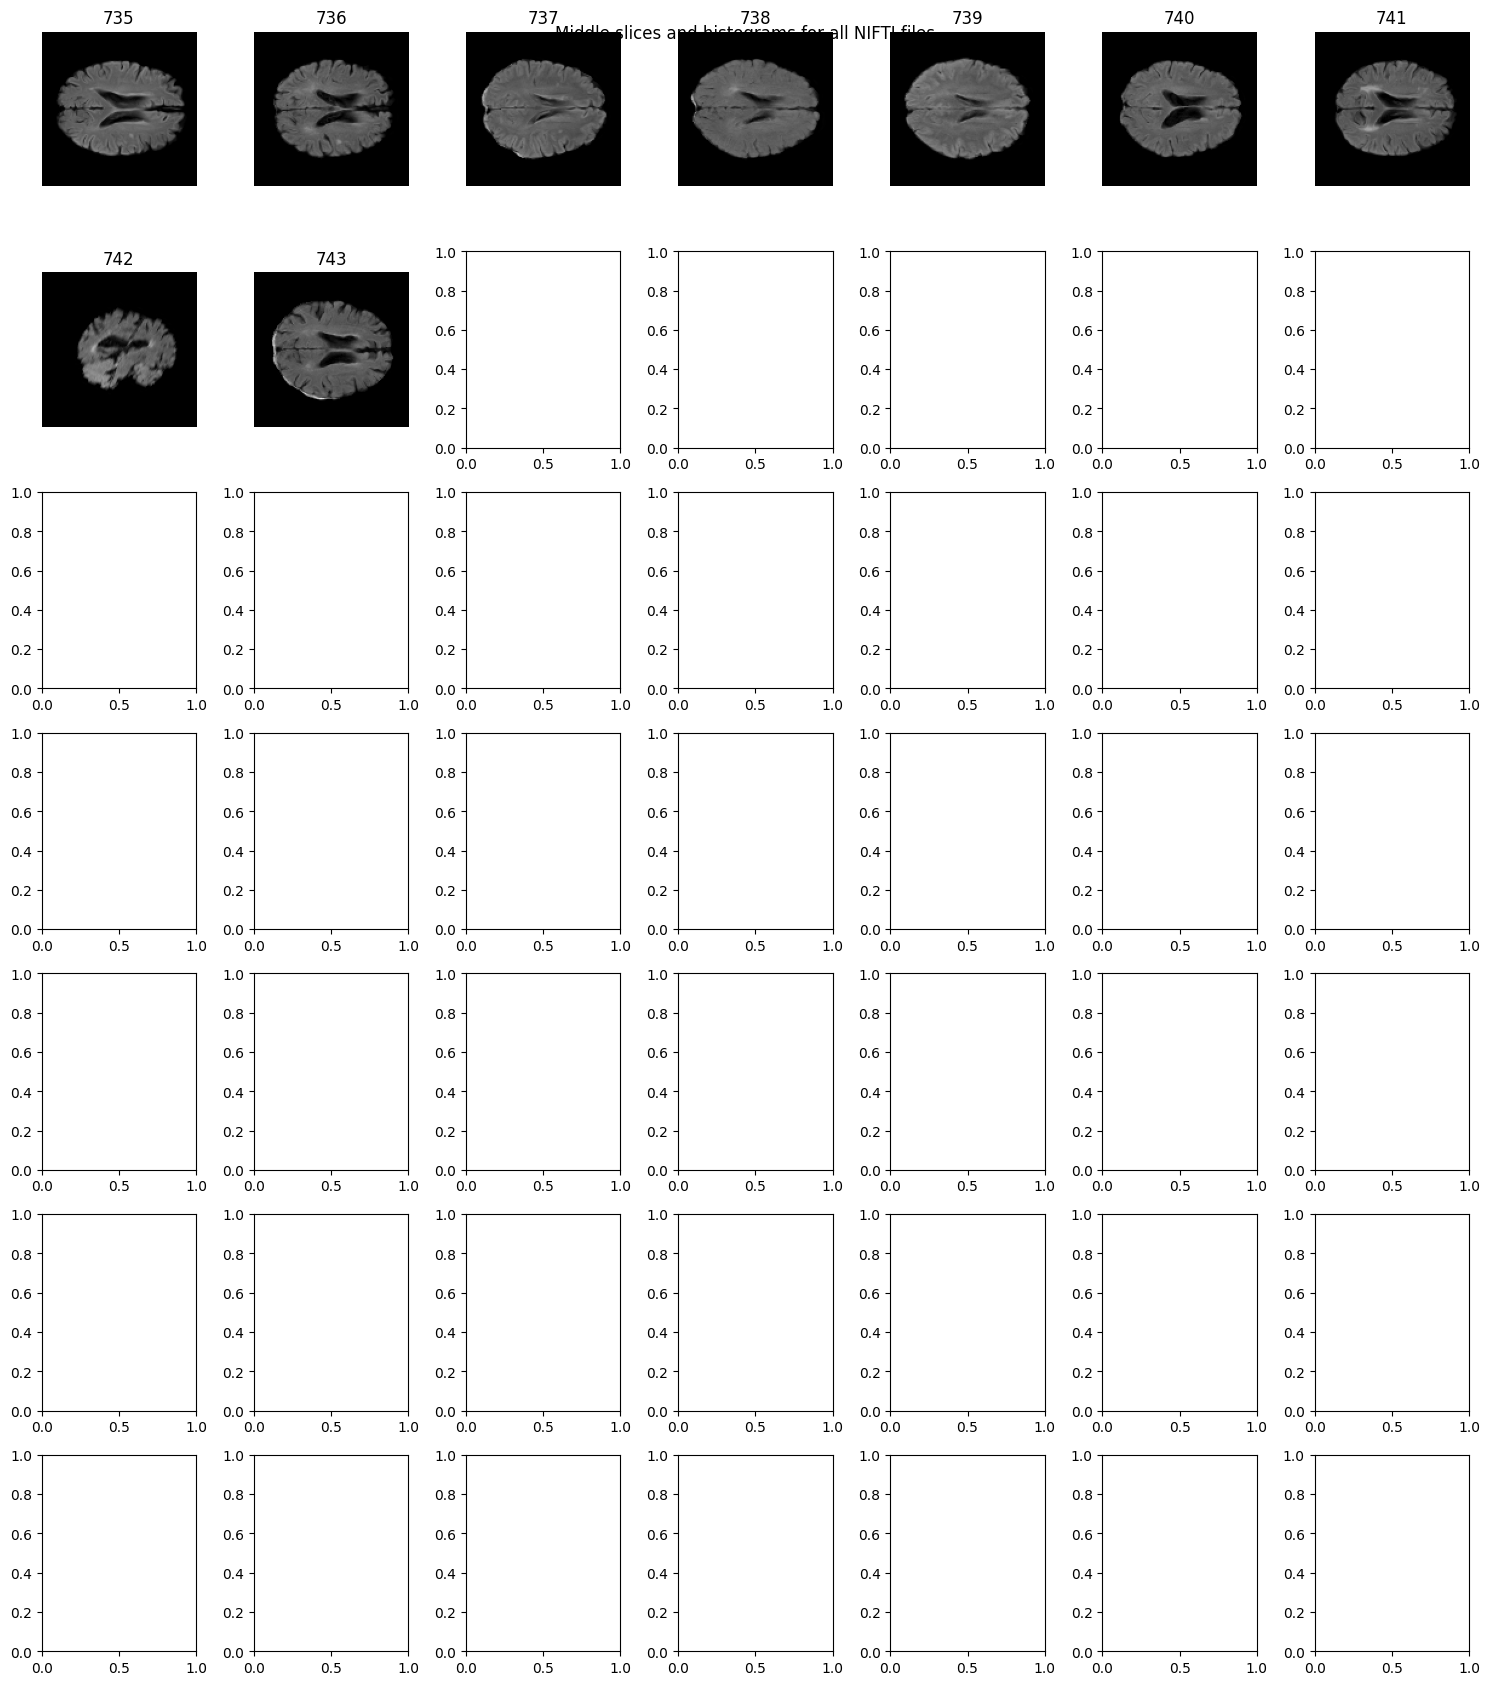

In [31]:
display_middle_slice_z(folder_path=final_flair_dataset_small_oasis, nb_images=49, page_number=15, figsize=15, normalize_from_histogram_peak=True, hist_norm_target_value=200, max_display_value=550)

In [ ]:
display_middle_slice_z_with_histogram(folder_path=final_adc_dataset_small_ixi, nb_images=25, page_number=15, figsize=30, normalize_from_histogram_peak=True, hist_norm_target_value=1000, max_display_value=6000)

In [ ]:
display_middle_slice_z_with_histogram(folder_path=final_flair_dataset_small_brats, nb_images=25, page_number=0, figsize=25, normalize_from_histogram_peak=True, hist_norm_target_value=200, max_display_value=550)

In [ ]:
display_middle_slice_z_with_histogram(folder_path=final_adc_dataset_small_HCP_YA, nb_images=25, page_number=0, figsize=25, normalize_from_histogram_peak=True, hist_norm_target_value=1000)

In [ ]:
display_middle_slice_z_with_histogram(folder_path=final_adc_dataset_small_Dallas, nb_images=25, page_number=0, figsize=25, normalize_from_histogram_peak=True, hist_norm_target_value=1000)

In [ ]:
display_middle_slice_z_with_histogram(folder_path=final_adc_dataset_small_AINI_stroke_ait, nb_images=25, page_number=0, figsize=25, normalize_from_histogram_peak=True, hist_norm_target_value=1000)

### Visualize with monai transforms

In [9]:

train_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/train.csv")
train_images_path = []

with open(train_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        train_images_path.append(ROOT_DIR+line[0])

val_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/val.csv")
val_images_path = []

with open(val_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        val_images_path.append(ROOT_DIR+line[0])



#train_datalist = sorted(train_images_path)
train_datalist = train_images_path

#val_datalist = sorted(val_images_path)
val_datalist = val_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

batch_size = 64 # 32
num_workers = 16 # 4*num_gpus, 4*world_size

train_transforms = transforms.Compose(
[
    transforms.LoadImage(image_only=True),
    transforms.EnsureChannelFirst(),
    transforms.RandAffine(prob=0.5, rotate_range=(0.10, 0.10, 0.10)),#+- 0.15 radians for each axis
    #transforms.EnsureType(device=device, track_meta=False),(didn't work error) # convert the data to Tensor without meta, move to GPU and cache to avoid CPU -> GPU sync in every epoch
    custom_transforms.Get2DSliceWithRandomOffset(axis=2, fixed_offset=0, range_offset=10),
    transforms.RandScaleCrop(roi_scale=0.9, max_roi_scale=1.1, random_size=True),
    transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
    custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
    transforms.ScaleIntensityRange(a_min=0.0, a_max=450.0, b_min=0.0, b_max=1.0, clip=True),
    transforms.RandFlip(prob=0.5, spatial_axis=0),
    custom_transforms.SetBackgroundToZero()
])

train_ds = CacheDataset(data=train_datalist[:batch_size], transform=train_transforms) #TODO datalist[:32]
train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True
)

758it [00:00, 193858.68it/s]
95it [00:00, 59873.61it/s]
Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:09<00:00,  6.46it/s]


In [ ]:
# Get the first batch of images from the train_loader
batch = next(iter(train_loader))

# Extract the images from the batch
images = batch  # Assuming the first element in the batch is the image tensor

# Plot the first 16 images
fig, axes = plt.subplots(8, 8, figsize=(20, 20))
for i, ax in enumerate(axes.flatten()):
    #print(images.shape)
    ax.imshow(images[i, 0, :, :].cpu().numpy(), cmap='gray', vmin=0, vmax=1)  # Assuming images are single-channel
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
bad_dallas_flair = [236]
bad_dallas_flair_names = os.listdir(final_flair_dataset_small_dallas)[236]

bad_lemon_flair = [148]
bad_lemon_flair_names = os.listdir(final_flair_dataset_small_lemon)[148]

print("Bad Dallas FLAIR files names:", bad_dallas_flair_names)
print("Bad lemon FLAIR files names:", bad_lemon_flair_names)

Bad Dallas FLAIR files names: sub-4799_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz
Bad lemon FLAIR files names: sub-032360_ses-01_acq-lowres_FLAIR.nii.gz


### Compare histograms from hcp, dallas and aini stroke

In [ ]:
bad_files = ["sub-3242_ses-wave2_ADC.nii.gz", 
            "aini-stroke-17579_425560_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz",
            "aini-stroke-13607_424097_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz"]

def display_mean_histogram(folder_path):
    # List all files in the folder
    files = os.listdir(folder_path)

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices
    plt.figure(figsize=(10, 10))

    data_sum = []
    skipped_files = 0

    for i, nifti_file in enumerate(tqdm(nifti_files)):
        if nifti_file not in bad_files:
            # Load the NIFTI image
            img_path = os.path.join(folder_path, nifti_file)
            img = nib.load(img_path)
            data = img.get_fdata()
            if len(data_sum) ==0:
                data_sum.append(data.flatten())
            else:
                data_sum[0] += data.flatten()
        else:
            print(f"Skipping bad file: {nifti_file}")
            skipped_files += 1
    
    mean_data = data_sum[0]/(len(nifti_files)-skipped_files)

    # Set the title of the figure
    plt.title(f'Mean histogram of all NIFTI files in {folder_path} (skipped {skipped_files} bad files)')
    plt.hist(mean_data[(mean_data>1) & (mean_data<=3000)], 100)
    # Show the plot
    plt.show()



In [ ]:
display_mean_histogram(final_flair_dataset_small_dallas)
display_mean_histogram(final_flair_dataset_small_lemon)
